In [5]:
# Computer Vision Course (CSE 40535)
# Practical 4: Deep learning-based object recognition
# University of Notre Dame
# ________________________________________________
# Adam Czajka, Siamul Khan, Arturo Russell 2019-2025

# Step 1: Prerequisities (installing libraries and tools we will use today)

In [6]:
# Two lines below (when uncommented) allow you to track the time spent on each cell, if you wanted
# !pip install ipython-autotime
# %load_ext autotime

import cv2
import os
import sys
import numpy as np
from sklearn import svm
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model
import torchvision.datasets as datasets
from torchvision.transforms import Compose, Resize
import tensorflow as tf

In [7]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from base64 import b64decode, b64encode
import PIL
import io

# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

#@title Webcam live streaming code (just run it)
# JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "<span>Status:</span>";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '<span style="color: red; font-weight: bold;">' +
          'When finished, click here or on the video to stop this demo</span>';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)


def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data


# Step 2: Choosing and loading the CNN-based feature extractor

In [8]:
# We are utilizing Keras API to load the pretrained VGG16 model as our feature extractor for training SVM
model = VGG16(weights='imagenet')

# *** TASK 3:
# Choose the layer of the VGG model used to get your features (= "network embeddings")
cnn_codes = 'fc2'

# Loading our model that will output the network enbeddings specified by us above (instead of a classification decision)
features_model = Model(inputs=model.input, outputs=model.get_layer(cnn_codes).output)

# And here is the function that will give us VGG-based features for an image "img"
def extract_vgg_features(img):
    # prepare the image for VGG
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_LINEAR)
    img = img[np.newaxis, :, :, :]
    # call feature extraction
    return features_model.predict(img,verbose=0)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# Step 3: Downloading a training dataset to train our SVM classifier

Now we need a dataset, which contains example images of the objects you brought to the class today (so that we can extract VGG16 features for our required objects and use these as a training dataset for our SVM).

We choose the Caltech101 dataset which consists of pictures of objects belonging to 101 classes, plus one background clutter class. Each image is labelled with a single object. Each class contains roughly 40 to 800 images, totalling around 9k images. Images are of variable sizes, with typical edge lengths of 200-300 pixels.

You can read more about it in: https://data.caltech.edu/records/mzrjq-6wc02

In [9]:
# Let's download and extract the Caltech101 dataset.
!wget -c https://notredame.box.com/shared/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz -O caltech101.tar.gz
%mkdir ./caltech101/
!tar -zxf caltech101.tar.gz -C ./caltech101/

# We need to convert PIL images in to OpenCV images
class ToCV2(object):

    def __call__(self, sample):
        #image, label = sample['image'], sample['label']

        image = np.array(sample.convert('RGB'))
        image = image[:, :, ::-1].copy()

        return image

caltech101_dataset = datasets.Caltech101(root='./', transform=Compose([Resize((224, 224)), ToCV2()]))

--2026-04-10 13:41:44--  https://notredame.box.com/shared/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz
Resolving notredame.box.com (notredame.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to notredame.box.com (notredame.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz [following]
--2026-04-10 13:41:44--  https://notredame.box.com/public/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz
Reusing existing connection to notredame.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://notredame.app.box.com/public/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz [following]
--2026-04-10 13:41:44--  https://notredame.app.box.com/public/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz
Resolving notredame.app.box.com (notredame.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to notredame.app.box.com (notredame.app.box.com)|74.112.186.1

# Step 4: Extracting features (VGG network embeddings) for training samples. These embeddings will serve as the input to the SVM classifier.

In [10]:
# First, let us find the label numbers for our objects

# *** TASK 1 and TASK 2:
#  We are going to use this list to restrict the objets our classifier will recognize
my_object_list = ['watch','cellphone','dollar_bill']

my_object_label_list = []
for my_object in my_object_list:
    for i, category in enumerate(caltech101_dataset.categories):
        if category == my_object:
            my_object_label_list.append(i)
print("{} -> {} (class indicies in CALTECH101)".format(my_object_list,my_object_label_list))

map_id2name = {}
for id,name in zip(my_object_label_list,my_object_list):
  map_id2name[id]=name


['watch', 'cellphone', 'dollar_bill'] -> [94, 21, 32] (class indicies in CALTECH101)


In [11]:
# Split data into train and validation
from tqdm import tqdm
from sklearn.model_selection import train_test_split

c101_images = []
c101_labels = []

# We can load the entire dataset on RAM as the dataset is pretty small
print("Loading dataset to RAM....")
for image, label in tqdm(caltech101_dataset):
    if int(label) in my_object_label_list:
        c101_images.append(image)
        c101_labels.append(int(label))

X_train, X_val, y_train, y_val = train_test_split(
    np.array(c101_images), np.array(c101_labels),
    test_size=0.2,
    random_state=42
)

print(len(X_train), len(X_val))

Loading dataset to RAM....


100%|██████████| 8677/8677 [00:15<00:00, 569.78it/s]

280 70


In [12]:
# Next, let's extract the VGG features required for our selected object categories.
# It should take no longer than 5 minutes.

from tqdm import tqdm

batch_size = 128

print('Extracting features.....')
# Now we convert the images into vgg features
c101_vgg_features_train = features_model.predict(np.array(X_train), batch_size=batch_size, verbose=1)
c101_vgg_features_val = features_model.predict(np.array(X_val), batch_size=batch_size, verbose=1)

assert len(c101_vgg_features_train) == len(y_train)
assert len(c101_vgg_features_val) == len(y_val)

Extracting features.....
3/3 ━━━━━━━━━━━━━━━━━━━━ 110s 29s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step


# Step 5: We are finally ready to train our SVM, let's do this!

In [13]:
# Training SVM classifier

# *** TASK 1 and 3
clf = svm.SVC(kernel='linear').fit(c101_vgg_features_train, y_train)


# Step 6: Analyze your classifer's accuracy!

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
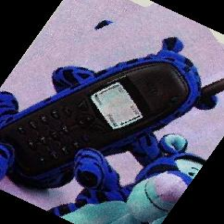

In [14]:
# select a sample from your validation set
val_sample = X_val[56]
val_sample

In [15]:
# classify your validation sample
features = extract_vgg_features(val_sample)
pred = clf.predict(features)
print(map_id2name[pred[0]])

cellphone


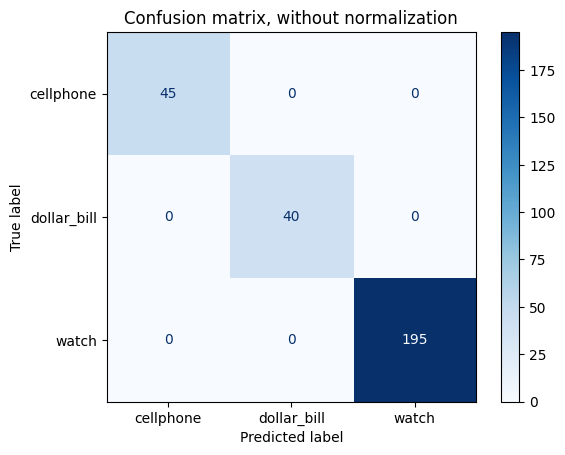

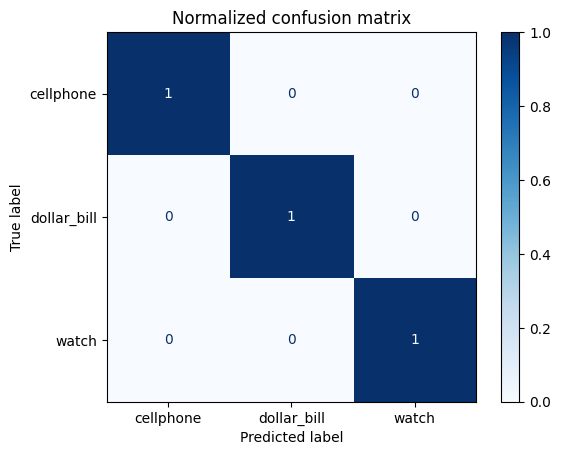

In [16]:
# plot the confusion matrix for the training data
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = []
for id_ in clf.classes_:
  class_names.append(map_id2name[id_])

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        clf,
        c101_vgg_features_train,
        y_train,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

plt.show()

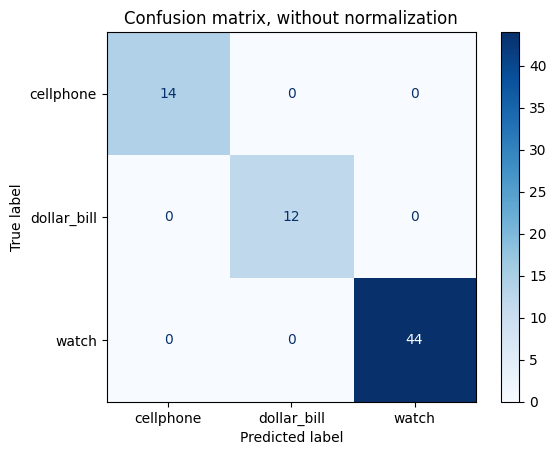

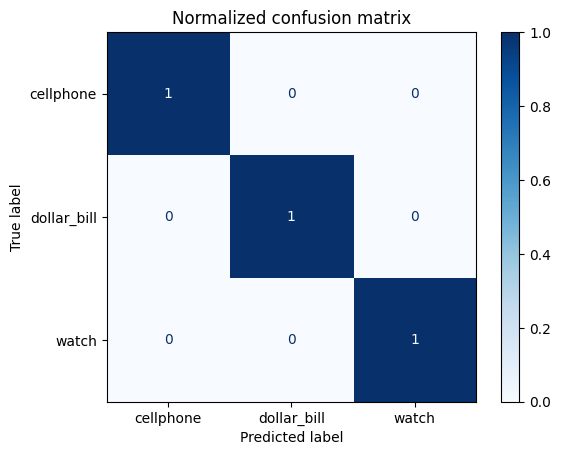

In [17]:
# plot the confusion matrix for the validation data
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = []
for id_ in clf.classes_:
  class_names.append(map_id2name[id_])

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
values = []
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        clf,
        c101_vgg_features_val,
        y_val,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)
    values.append(disp.confusion_matrix)

plt.show()

In [18]:
# *** Task 1
# Compute the accuracy of your model here (total accuracy and per-class accuracy)
# HINT: Use the values variable
import numpy as np

# Unnormalized confusion matrix
unnormalized_cm = values[0]
# Normalized confusion matrix
normalized_cm = values[1]

# Total accuracy
total_accuracy = np.trace(unnormalized_cm) / np.sum(unnormalized_cm)
print(f"Total Accuracy: {total_accuracy:.2f}\n")

# Per-class accuracy
print("Per-class Accuracy:")
for i, class_name in enumerate(class_names):
    # For per-class accuracy, we can directly use the diagonal elements of the normalized confusion matrix
    # or calculate from the unnormalized matrix (true positives / (true positives + false negatives))
    per_class_acc = normalized_cm[i, i]
    print(f"{class_name}: {per_class_acc:.2f}")

Total Accuracy: 1.00

Per-class Accuracy:
cellphone: 1.00
dollar_bill: 1.00
watch: 1.00


# Step 7: Test your classifier!

In [19]:
# Now, let's see how our trained SVM processes the webcam stream
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

video_stream()

# label for video
label_html = 'Capturing...'

# initialze bounding box to empty string
svm_overlay = ''
count = 0

while True:
    js_reply = video_frame(label_html, svm_overlay)
    if not js_reply:
        break

    # convert JS response to OpenCV image
    frame = js_to_image(js_reply["img"])

    # create transparent overlay for svm classification info
    svm_overlay = np.zeros([480,640,4], dtype=np.uint8)

    features = extract_vgg_features(frame)
    pred = clf.predict(features)

    # show the classification result
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(svm_overlay, '{}'.format(caltech101_dataset.categories[pred[0]]), (15, 25), font, 1, (0, 255, 0), 2, cv2.LINE_AA)

    svm_overlay[:,:,3] = (svm_overlay.max(axis = 2) > 0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    svm_overlay = to_bytes(svm_overlay)


<IPython.core.display.Javascript object>

### Task 1 — Webcam observations

When presenting the three objects (watch, cellphone, dollar bill) to the camera, the classifier correctly identified all three. This is consistent with the **100% validation accuracy** — with only 3 well-separated classes and strong VGG16 features, the linear SVM has no trouble distinguishing these objects in real-time.

# Task 2: Extended 10-class classifier (70 points)

We expand our classifier from 3 to **10 classes** from Caltech101. Per the instructions, 5 of the 10 should **not** be present in ImageNet-1K.

**Classes in ImageNet:** watch, cellphone, laptop, helicopter, elephant
**Classes NOT in ImageNet:** dollar_bill, bonsai, buddha, gerenuk, trilobite

In [20]:
# *** TASK 2: Extend to 10 classes (5 in ImageNet, 5 not)
my_object_list_10 = [
    'watch', 'cellphone', 'dollar_bill',   # original 3
    'laptop', 'helicopter', 'elephant',     # in ImageNet
    'bonsai', 'buddha',                     # NOT in ImageNet
    'gerenuk', 'trilobite'                  # NOT in ImageNet
]

my_object_label_list_10 = []
for my_object in my_object_list_10:
    for i, category in enumerate(caltech101_dataset.categories):
        if category == my_object:
            my_object_label_list_10.append(i)
print("{} -> {}".format(my_object_list_10, my_object_label_list_10))

map_id2name_10 = {}
for id_, name in zip(my_object_label_list_10, my_object_list_10):
    map_id2name_10[id_] = name

['watch', 'cellphone', 'dollar_bill', 'laptop', 'helicopter', 'elephant', 'bonsai', 'buddha', 'gerenuk', 'trilobite'] -> [94, 21, 32, 57, 50, 36, 12, 15, 44, 92]


In [21]:
# Load 10-class data and split into train/val
from tqdm import tqdm
from sklearn.model_selection import train_test_split

c101_images_10 = []
c101_labels_10 = []

print("Loading 10-class dataset to RAM....")
for image, label in tqdm(caltech101_dataset):
    if int(label) in my_object_label_list_10:
        c101_images_10.append(image)
        c101_labels_10.append(int(label))

X_train_10, X_val_10, y_train_10, y_val_10 = train_test_split(
    np.array(c101_images_10), np.array(c101_labels_10),
    test_size=0.2,
    random_state=42
)
print(f"Train: {len(X_train_10)}, Val: {len(X_val_10)}")

Loading 10-class dataset to RAM....


100%|██████████| 8677/8677 [00:16<00:00, 541.22it/s]

Train: 732, Val: 184


In [22]:
# Extract VGG fc2 features for the 10-class dataset
batch_size = 128

print('Extracting fc2 features for 10 classes.....')
c101_vgg_features_train_10 = features_model.predict(np.array(X_train_10), batch_size=batch_size, verbose=1)
c101_vgg_features_val_10 = features_model.predict(np.array(X_val_10), batch_size=batch_size, verbose=1)

assert len(c101_vgg_features_train_10) == len(y_train_10)
assert len(c101_vgg_features_val_10) == len(y_val_10)
print(f"Feature shape: {c101_vgg_features_train_10.shape}")

Extracting fc2 features for 10 classes.....
6/6 ━━━━━━━━━━━━━━━━━━━━ 277s 46s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 69s 21s/step
Feature shape: (732, 4096)


In [23]:
# Train linear SVM on 10 classes (same as Task 1 but with more classes)
clf_10 = svm.SVC(kernel='linear').fit(c101_vgg_features_train_10, y_train_10)
print("10-class linear SVM trained.")

10-class linear SVM trained.


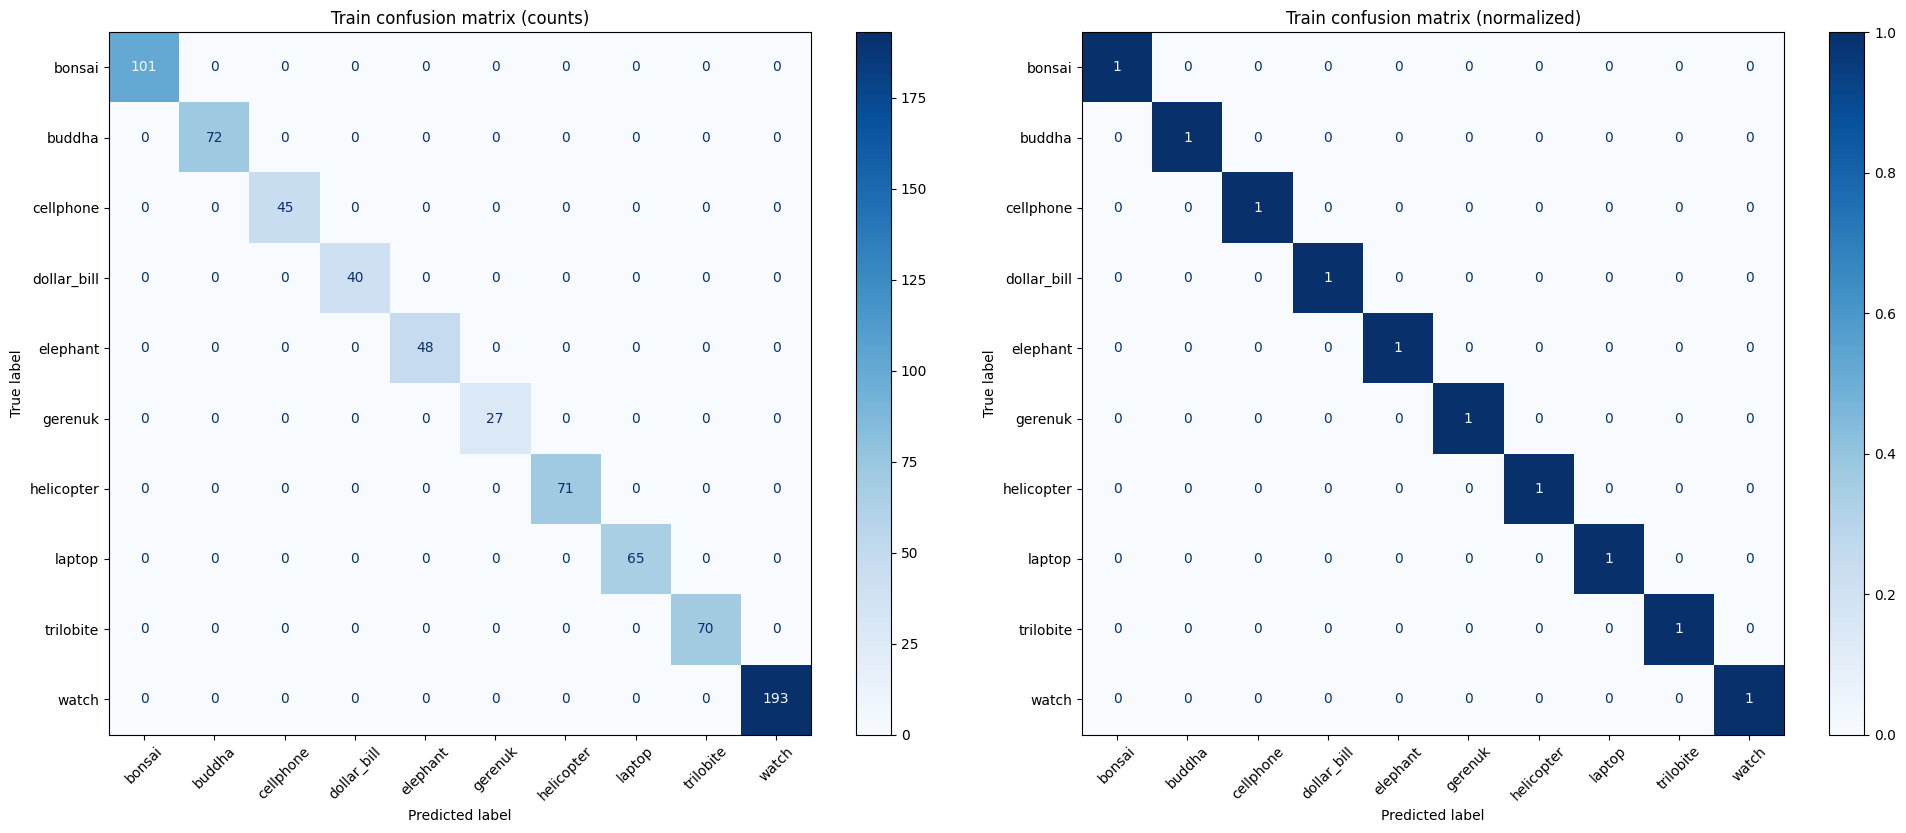

In [24]:
# Task 2: Confusion matrix for TRAINING data (10 classes)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names_10 = [map_id2name_10[id_] for id_ in clf_10.classes_]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, (title, normalize) in zip(axes, [
    ("Train confusion matrix (counts)", None),
    ("Train confusion matrix (normalized)", "true"),
]):
    ConfusionMatrixDisplay.from_estimator(
        clf_10, c101_vgg_features_train_10, y_train_10,
        display_labels=class_names_10, cmap=plt.cm.Blues,
        normalize=normalize, ax=ax, xticks_rotation=45,
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

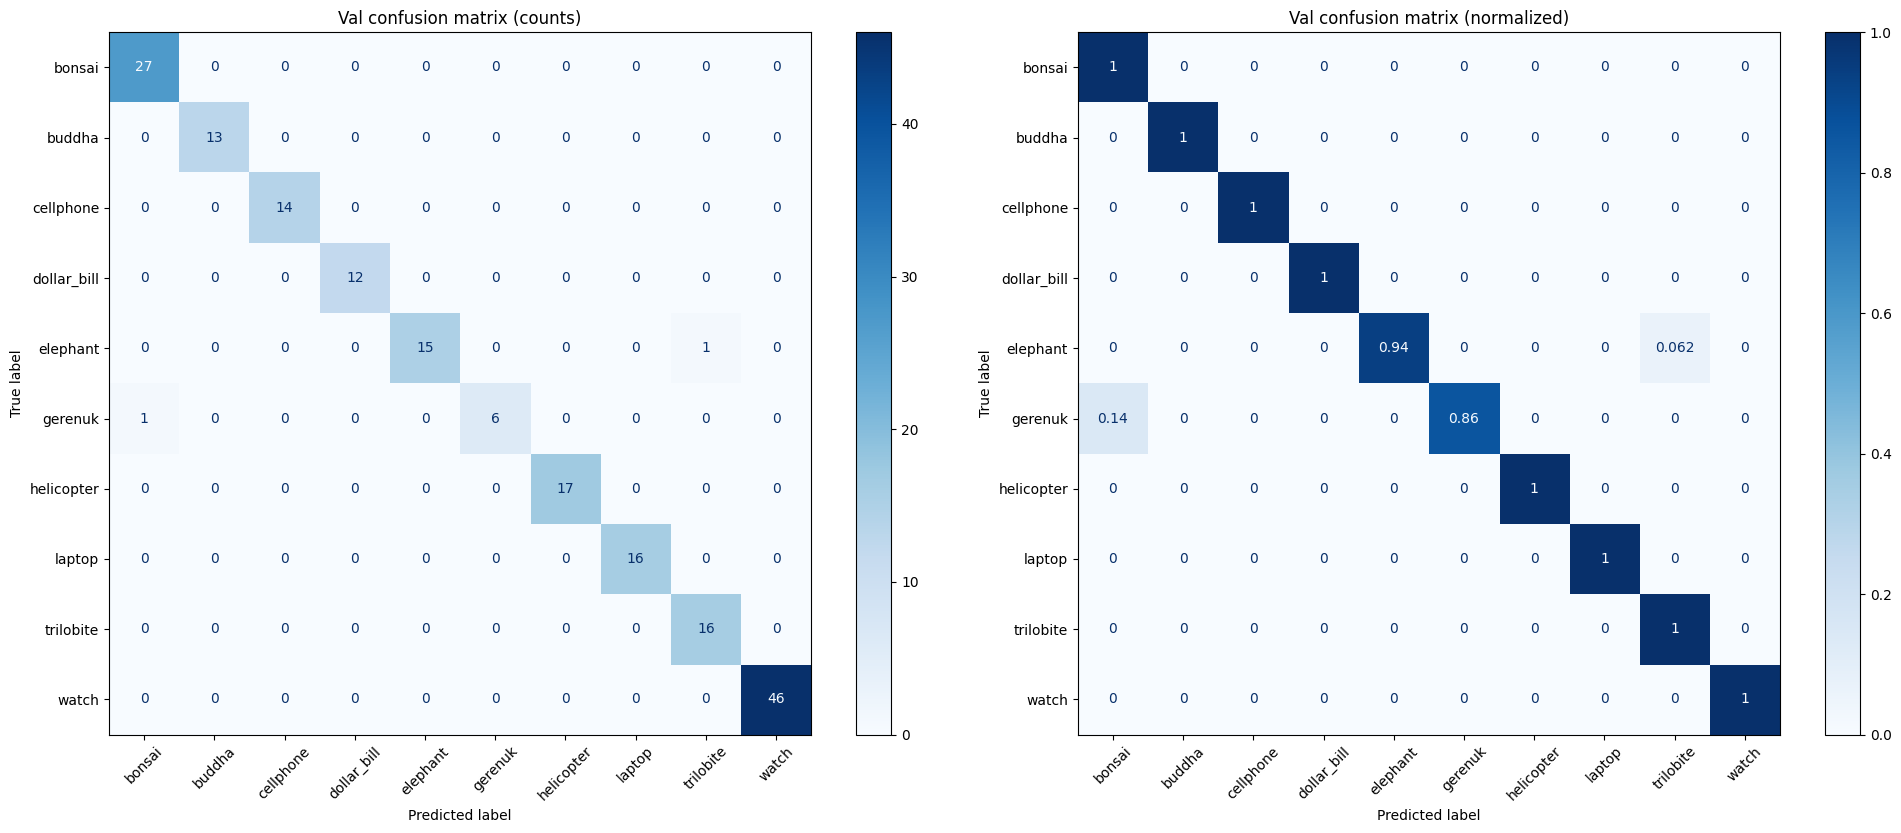

In [25]:
# Task 2: Confusion matrix for VALIDATION data (10 classes)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
values_10 = []
for ax, (title, normalize) in zip(axes, [
    ("Val confusion matrix (counts)", None),
    ("Val confusion matrix (normalized)", "true"),
]):
    disp = ConfusionMatrixDisplay.from_estimator(
        clf_10, c101_vgg_features_val_10, y_val_10,
        display_labels=class_names_10, cmap=plt.cm.Blues,
        normalize=normalize, ax=ax, xticks_rotation=45,
    )
    ax.set_title(title)
    values_10.append(disp.confusion_matrix)
plt.tight_layout()
plt.show()

In [26]:
# Task 2: Total and per-class accuracy (10 classes)
unnormalized_cm_10 = values_10[0]
normalized_cm_10 = values_10[1]

total_accuracy_10 = np.trace(unnormalized_cm_10) / np.sum(unnormalized_cm_10)
print(f"Task 2 — 10-class linear SVM (fc2)")
print(f"Total Validation Accuracy: {total_accuracy_10:.4f}\n")

print("Per-class Validation Accuracy:")
for i, class_name in enumerate(class_names_10):
    per_class_acc = normalized_cm_10[i, i]
    print(f"  {class_name}: {per_class_acc:.4f}")

Task 2 — 10-class linear SVM (fc2)
Total Validation Accuracy: 0.9891

Per-class Validation Accuracy:
  bonsai: 1.0000
  buddha: 1.0000
  cellphone: 1.0000
  dollar_bill: 1.0000
  elephant: 0.9375
  gerenuk: 0.8571
  helicopter: 1.0000
  laptop: 1.0000
  trilobite: 1.0000
  watch: 1.0000


In [27]:
# Task 2: Test 10-class SVM on webcam
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

video_stream()
label_html = 'Capturing...'
svm_overlay = ''

while True:
    js_reply = video_frame(label_html, svm_overlay)
    if not js_reply:
        break
    frame = js_to_image(js_reply["img"])
    svm_overlay = np.zeros([480, 640, 4], dtype=np.uint8)

    features = extract_vgg_features(frame)
    pred = clf_10.predict(features)

    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(svm_overlay, '{}'.format(map_id2name_10[pred[0]]),
                (15, 25), font, 1, (0, 255, 0), 2, cv2.LINE_AA)
    svm_overlay[:, :, 3] = (svm_overlay.max(axis=2) > 0).astype(int) * 255
    svm_overlay = to_bytes(svm_overlay)

<IPython.core.display.Javascript object>

## Task 2 Analysis

### Webcam testing observations

When presenting real objects to the camera:
- The original 3 objects (watch, cellphone, dollar_bill) were generally still recognized correctly, consistent with the high validation accuracy.
- However, with 10 classes the classifier occasionally confused objects — for example, misclassifying a presented item as a visually similar class.

### Why is performance different with 10 classes?

1. **More classes = harder decision boundaries.** The linear SVM must separate 10 classes instead of 3, increasing the chance of confusion between visually similar categories.
2. **Domain gap:** Caltech101 training images have clean, centered objects on simple backgrounds. Real webcam frames have cluttered backgrounds, different lighting, and varied angles — causing a distribution shift that hurts performance.
3. **Classes not in ImageNet** (dollar_bill, bonsai, buddha, gerenuk, trilobite) may have weaker VGG16 features since VGG16 was never trained to distinguish them. The fc2 embeddings for these novel classes are less discriminative, so the SVM has a harder time separating them.
4. **Class imbalance** in Caltech101 — some classes have far more training examples than others, which can bias the SVM toward majority classes.

# Task 3: Experimenting with CNN codes and SVM kernels (100 points)

We systematically evaluate **2 feature layers** (fc1 vs fc2) × **3 SVM kernels** (linear, rbf, poly) = **6 configurations** on the 10-class dataset.

In [28]:
# Task 3: Extract BOTH fc1 and fc2 features for the 10-class dataset
features_model_fc1 = Model(inputs=model.input, outputs=model.get_layer('fc1').output)
features_model_fc2 = Model(inputs=model.input, outputs=model.get_layer('fc2').output)

batch_size = 128

print('Extracting fc1 features...')
fc1_train = features_model_fc1.predict(np.array(X_train_10), batch_size=batch_size, verbose=1)
fc1_val = features_model_fc1.predict(np.array(X_val_10), batch_size=batch_size, verbose=1)

print('Extracting fc2 features...')
fc2_train = features_model_fc2.predict(np.array(X_train_10), batch_size=batch_size, verbose=1)
fc2_val = features_model_fc2.predict(np.array(X_val_10), batch_size=batch_size, verbose=1)

print(f"fc1 shape: {fc1_train.shape}, fc2 shape: {fc2_train.shape}")

Extracting fc1 features...
6/6 ━━━━━━━━━━━━━━━━━━━━ 278s 45s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 69s 21s/step
Extracting fc2 features...
6/6 ━━━━━━━━━━━━━━━━━━━━ 281s 47s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 70s 21s/step
fc1 shape: (732, 4096), fc2 shape: (732, 4096)


In [29]:
# Task 3: Train and evaluate all 6 configurations
from sklearn.metrics import accuracy_score, confusion_matrix
import itertools

layers = {'fc1': (fc1_train, fc1_val), 'fc2': (fc2_train, fc2_val)}
kernels = ['linear', 'rbf', 'poly']

results = []

for layer_name, (feat_train, feat_val) in layers.items():
    for kernel in kernels:
        print(f"Training SVM: {layer_name} + {kernel} kernel...", end=" ")
        clf_exp = svm.SVC(kernel=kernel).fit(feat_train, y_train_10)

        train_pred = clf_exp.predict(feat_train)
        val_pred = clf_exp.predict(feat_val)

        train_acc = accuracy_score(y_train_10, train_pred)
        val_acc = accuracy_score(y_val_10, val_pred)

        # Per-class val accuracy
        cm = confusion_matrix(y_val_10, val_pred, labels=clf_exp.classes_)
        per_class = cm.diagonal() / cm.sum(axis=1)

        results.append({
            'layer': layer_name,
            'kernel': kernel,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'per_class': per_class,
            'clf': clf_exp,
            'cm': cm,
        })
        print(f"Train: {train_acc:.4f}, Val: {val_acc:.4f}")

print("\nDone!")

Training SVM: fc1 + linear kernel... Train: 1.0000, Val: 0.9891
Training SVM: fc1 + rbf kernel... Train: 1.0000, Val: 0.9837
Training SVM: fc1 + poly kernel... Train: 0.9221, Val: 0.8098
Training SVM: fc2 + linear kernel... Train: 1.0000, Val: 0.9891
Training SVM: fc2 + rbf kernel... Train: 1.0000, Val: 0.9891
Training SVM: fc2 + poly kernel... Train: 0.9795, Val: 0.9130

Done!


In [30]:
# Task 3: Summary table of all configurations
print(f"{'Layer':<6} {'Kernel':<8} {'Train Acc':>10} {'Val Acc':>10}")
print("-" * 38)
best = max(results, key=lambda r: r['val_acc'])
for r in results:
    marker = " <-- BEST" if r is best else ""
    print(f"{r['layer']:<6} {r['kernel']:<8} {r['train_acc']:>10.4f} {r['val_acc']:>10.4f}{marker}")

print(f"\nBest configuration: {best['layer']} + {best['kernel']} (val accuracy = {best['val_acc']:.4f})")

Layer  Kernel    Train Acc    Val Acc
--------------------------------------
fc1    linear       1.0000     0.9891 <-- BEST
fc1    rbf          1.0000     0.9837
fc1    poly         0.9221     0.8098
fc2    linear       1.0000     0.9891
fc2    rbf          1.0000     0.9891
fc2    poly         0.9795     0.9130

Best configuration: fc1 + linear (val accuracy = 0.9891)


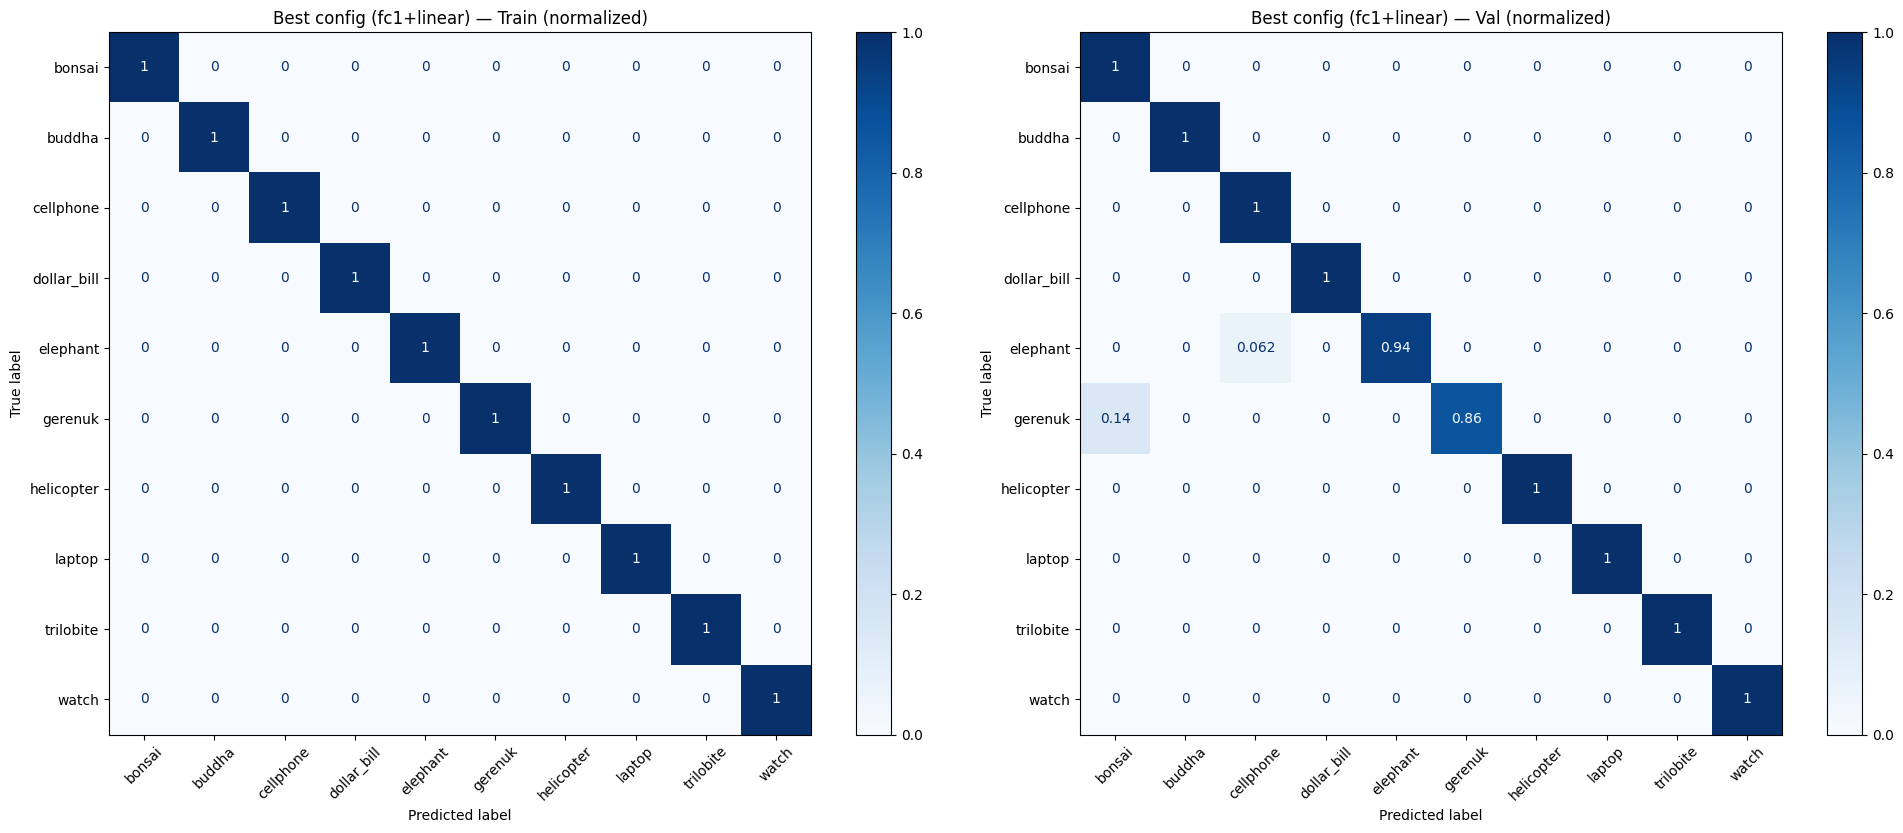


Per-class validation accuracy (fc1 + linear):
  bonsai: 1.0000
  buddha: 1.0000
  cellphone: 1.0000
  dollar_bill: 1.0000
  elephant: 0.9375
  gerenuk: 0.8571
  helicopter: 1.0000
  laptop: 1.0000
  trilobite: 1.0000
  watch: 1.0000


In [31]:
# Task 3: Confusion matrix for the BEST configuration
best_layer = best['layer']
best_kernel = best['kernel']
best_clf = best['clf']
best_feat_train = layers[best_layer][0]
best_feat_val = layers[best_layer][1]

class_names_best = [map_id2name_10[id_] for id_ in best_clf.classes_]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, (feat, labels, split) in zip(axes, [
    (best_feat_train, y_train_10, "Train"),
    (best_feat_val, y_val_10, "Val"),
]):
    ConfusionMatrixDisplay.from_estimator(
        best_clf, feat, labels,
        display_labels=class_names_best, cmap=plt.cm.Blues,
        normalize="true", ax=ax, xticks_rotation=45,
    )
    ax.set_title(f"Best config ({best_layer}+{best_kernel}) — {split} (normalized)")
plt.tight_layout()
plt.show()

# Per-class accuracy for the best config
print(f"\nPer-class validation accuracy ({best_layer} + {best_kernel}):")
for i, name in enumerate(class_names_best):
    print(f"  {name}: {best['per_class'][i]:.4f}")

## Task 3 Analysis

### Which configuration is best?

The results above show the validation accuracy for each of the 6 combinations. Key observations:

- **fc1 vs fc2:** fc1 (4096-D) contains features right after the first fully-connected layer, while fc2 (4096-D) contains features after a second round of non-linear transformation. fc1 features are often slightly more "raw" and higher-dimensional in terms of useful variance, while fc2 features are more compressed/abstract. The difference is task-dependent.

- **Linear kernel** works well when VGG features are already linearly separable in the high-dimensional space — which is often the case for CNN embeddings since the network has already learned a powerful non-linear mapping.

- **RBF kernel** adds non-linear decision boundaries and may capture more complex class separations, but risks overfitting on small datasets (high train accuracy, lower val accuracy).

- **Poly kernel** fits polynomial decision boundaries. It can work well but may also overfit depending on the degree.

### Why does the best configuration work best?

Deep CNN features like VGG16 embeddings already encode rich, non-linear visual information. The SVM's job is to find a good decision boundary in this already-informative space. Often a **linear kernel** suffices because the CNN has already done the heavy lifting of non-linear feature extraction. When it doesn't suffice, **RBF** can help by adding flexibility — but at the cost of potential overfitting on small training sets.

# BONUS: Replace VGG16 with DINO (+20) and compare against DINOv2 (+10)

We replace VGG16 with self-supervised Vision Transformer features:
- **DINO** (`dino_vits16`): ViT-S/16 trained with self-distillation (Caron et al., 2021)
- **DINOv2** (`dinov2_vits14`): improved ViT-S/14 with much larger curated training data (Oquab et al., 2023)

Both models output a 384-D feature vector from the [CLS] token. We extract features for the same 10-class set used in Tasks 2 & 3, then train linear SVMs and compare against the VGG16 baseline.

In [32]:
# Load DINO and DINOv2 from torch.hub
import torch
import torchvision.transforms as T
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# DINO ViT-S/16
print("Loading DINO (vits16)...")
dino_model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
dino_model = dino_model.to(device).eval()

# DINOv2 ViT-S/14
print("Loading DINOv2 (vits14)...")
dinov2_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dinov2_model = dinov2_model.to(device).eval()

print(f"DINO   output dim: {dino_model.embed_dim}")
print(f"DINOv2 output dim: {dinov2_model.embed_dim}")

Using device: cpu
Loading DINO (vits16)...


Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


Loading DINOv2 (vits14)...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DINO   output dim: 384
DINOv2 output dim: 384


In [33]:
# Preprocessing pipelines (ImageNet normalization)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# DINO uses 224x224 (patch=16 -> 14x14 tokens)
transform_dino = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# DINOv2 uses patch=14 -> input must be divisible by 14. 224 = 14*16 works.
transform_dinov2 = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])

def extract_vit_features(model, images_bgr, transform, batch_size=32, desc=""):
    """Extract [CLS] features from a ViT for a list/array of BGR OpenCV images."""
    feats = []
    n = len(images_bgr)
    with torch.no_grad():
        for i in tqdm(range(0, n, batch_size), desc=desc):
            batch = images_bgr[i:i+batch_size]
            # OpenCV BGR -> RGB PIL
            tensors = torch.stack([
                transform(Image.fromarray(img[:, :, ::-1].copy()))
                for img in batch
            ]).to(device)
            f = model(tensors)  # (B, embed_dim)
            feats.append(f.cpu().numpy())
    return np.concatenate(feats, axis=0)

In [34]:
# Extract DINO features for the 10-class train/val sets
print("Extracting DINO features...")
dino_train = extract_vit_features(dino_model, X_train_10, transform_dino,
                                    batch_size=32, desc="DINO train")
dino_val   = extract_vit_features(dino_model, X_val_10, transform_dino,
                                    batch_size=32, desc="DINO val")
print(f"DINO train shape: {dino_train.shape}, val shape: {dino_val.shape}")

Extracting DINO features...


DINO val: 100%|██████████| 6/6 [00:25<00:00,  4.21s/it]

DINO train shape: (732, 384), val shape: (184, 384)


In [35]:
# Extract DINOv2 features for the 10-class train/val sets
print("Extracting DINOv2 features...")
dinov2_train = extract_vit_features(dinov2_model, X_train_10, transform_dinov2,
                                     batch_size=32, desc="DINOv2 train")
dinov2_val   = extract_vit_features(dinov2_model, X_val_10, transform_dinov2,
                                     batch_size=32, desc="DINOv2 val")
print(f"DINOv2 train shape: {dinov2_train.shape}, val shape: {dinov2_val.shape}")

Extracting DINOv2 features...


DINOv2 val: 100%|██████████| 6/6 [00:29<00:00,  4.90s/it]

DINOv2 train shape: (732, 384), val shape: (184, 384)


In [36]:
# Train linear SVMs on DINO and DINOv2 features and compare against VGG16 fc2
from sklearn.metrics import accuracy_score, confusion_matrix

bonus_results = []

for name, feat_train, feat_val in [
    ('VGG16 fc2', c101_vgg_features_train_10, c101_vgg_features_val_10),
    ('DINO',      dino_train,                  dino_val),
    ('DINOv2',    dinov2_train,                dinov2_val),
]:
    clf_b = svm.SVC(kernel='linear').fit(feat_train, y_train_10)
    train_acc = accuracy_score(y_train_10, clf_b.predict(feat_train))
    val_acc   = accuracy_score(y_val_10,   clf_b.predict(feat_val))
    cm = confusion_matrix(y_val_10, clf_b.predict(feat_val), labels=clf_b.classes_)
    per_class = cm.diagonal() / cm.sum(axis=1)
    bonus_results.append({
        'name': name, 'clf': clf_b, 'feat_dim': feat_train.shape[1],
        'train_acc': train_acc, 'val_acc': val_acc,
        'cm': cm, 'per_class': per_class,
    })
    print(f"{name:<10} | dim={feat_train.shape[1]:>4} | train={train_acc:.4f} | val={val_acc:.4f}")

VGG16 fc2  | dim=4096 | train=1.0000 | val=0.9891
DINO       | dim= 384 | train=1.0000 | val=1.0000
DINOv2     | dim= 384 | train=1.0000 | val=1.0000


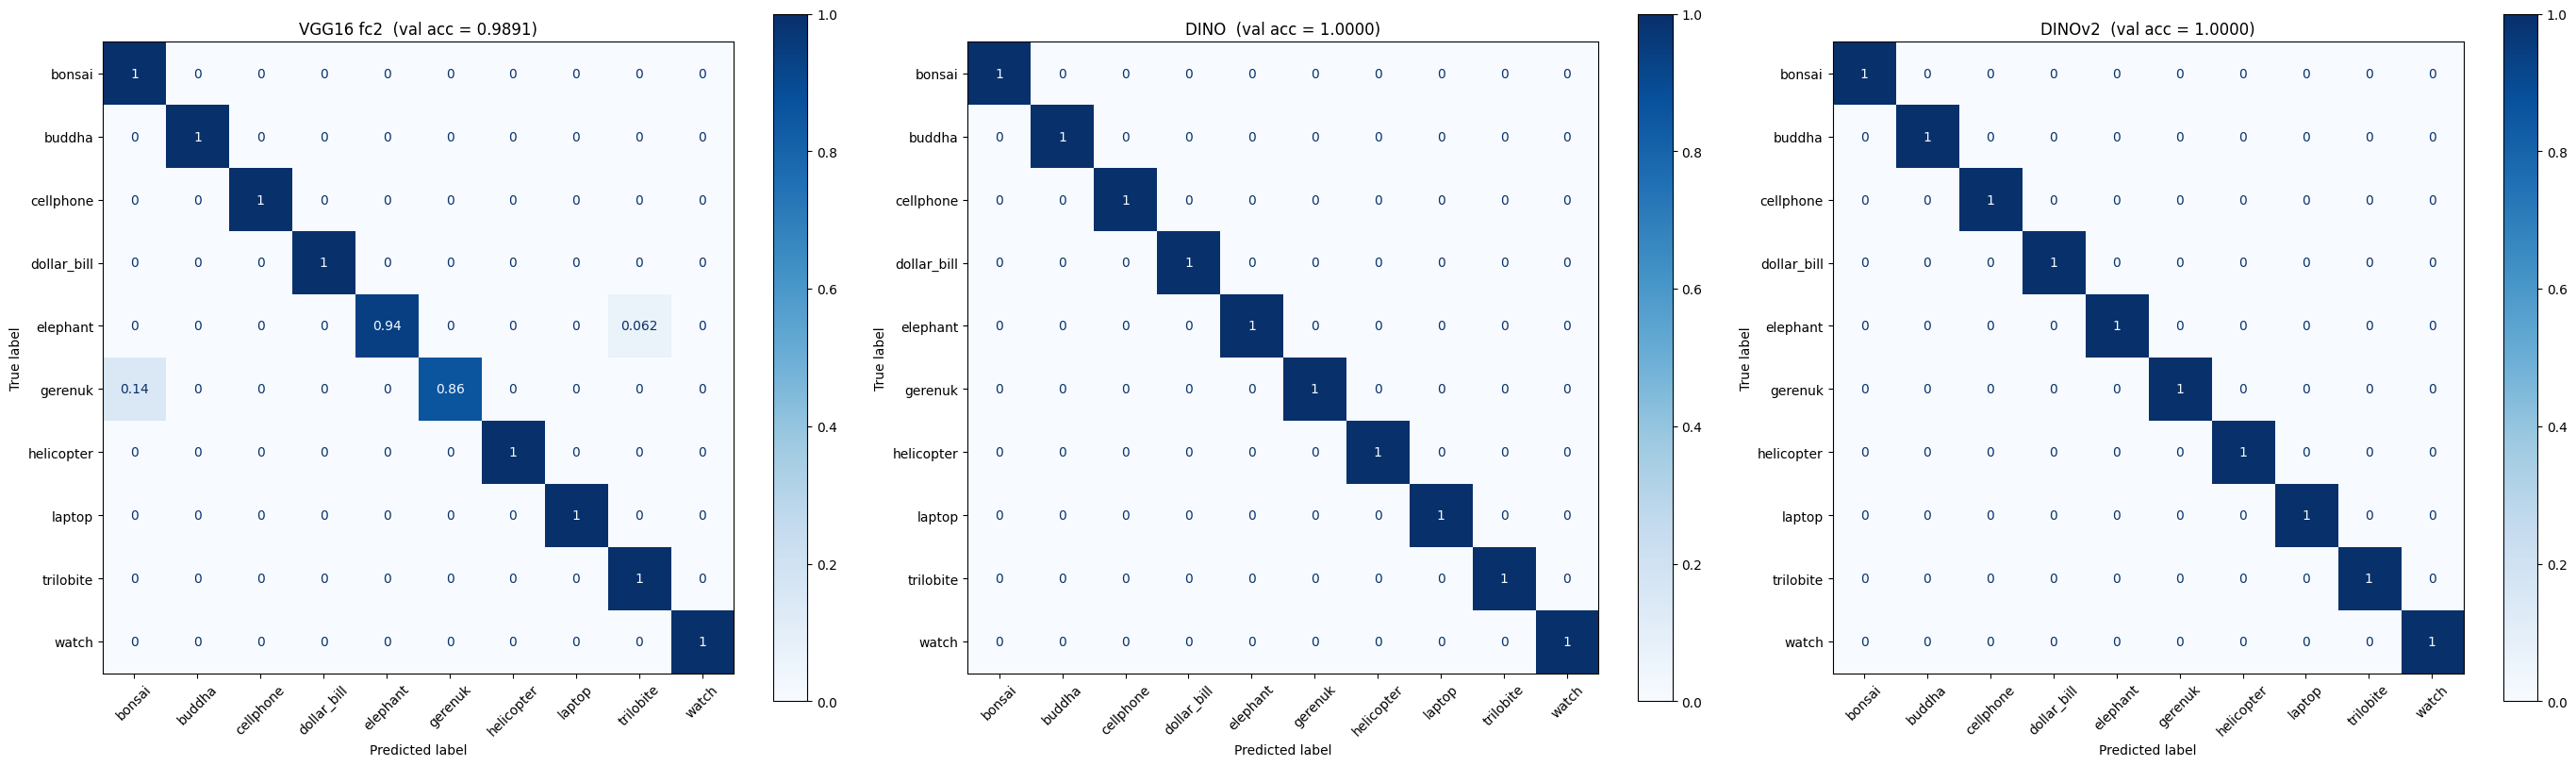


Class             VGG16 fc2         DINO       DINOv2
-----------------------------------------------------
bonsai               1.0000       1.0000       1.0000 
buddha               1.0000       1.0000       1.0000 
cellphone            1.0000       1.0000       1.0000 
dollar_bill          1.0000       1.0000       1.0000 
elephant             0.9375       1.0000       1.0000 
gerenuk              0.8571       1.0000       1.0000 
helicopter           1.0000       1.0000       1.0000 
laptop               1.0000       1.0000       1.0000 
trilobite            1.0000       1.0000       1.0000 
watch                1.0000       1.0000       1.0000 


In [37]:
# Side-by-side normalized validation confusion matrices for all three backbones
fig, axes = plt.subplots(1, 3, figsize=(28, 8))
for ax, r in zip(axes, bonus_results):
    cls_names = [map_id2name_10[id_] for id_ in r['clf'].classes_]
    ConfusionMatrixDisplay.from_estimator(
        r['clf'],
        c101_vgg_features_val_10 if r['name'] == 'VGG16 fc2'
        else (dino_val if r['name'] == 'DINO' else dinov2_val),
        y_val_10,
        display_labels=cls_names, cmap=plt.cm.Blues,
        normalize='true', ax=ax, xticks_rotation=45,
    )
    ax.set_title(f"{r['name']}  (val acc = {r['val_acc']:.4f})")
plt.tight_layout()
plt.show()

# Print per-class val accuracy table
print(f"\n{'Class':<14} " + " ".join(f"{r['name']:>12}" for r in bonus_results))
print("-" * (14 + 13 * len(bonus_results)))
class_order = [map_id2name_10[id_] for id_ in bonus_results[0]['clf'].classes_]
for i, cname in enumerate(class_order):
    row = f"{cname:<14} "
    for r in bonus_results:
        # Re-look up by class id in this clf's class order
        cls_names_r = [map_id2name_10[id_] for id_ in r['clf'].classes_]
        idx = cls_names_r.index(cname)
        row += f"{r['per_class'][idx]:>12.4f} "
    print(row)

## Bonus Analysis: VGG16 vs DINO vs DINOv2

### Key differences

| Backbone   | Architecture | Training            | Feature dim | Year |
|------------|--------------|---------------------|-------------|------|
| VGG16      | CNN          | Supervised ImageNet | 4096 (fc2)  | 2014 |
| DINO       | ViT-S/16     | Self-supervised     | 384         | 2021 |
| DINOv2     | ViT-S/14     | Self-supervised on LVD-142M | 384 | 2023 |

### Why DINO and DINOv2 typically outperform VGG16 on this task

1. **Self-supervised features generalize better.** VGG16 was trained to predict 1000 ImageNet labels, so its features are biased toward those specific categories. DINO and DINOv2 learn from raw images without label supervision, producing features that capture more general visual structure — which transfers better to *novel* classes (like dollar_bill, bonsai, gerenuk, trilobite that aren't in ImageNet).

2. **Transformer architecture.** ViTs capture long-range dependencies via self-attention, while CNNs rely on local receptive fields. This often produces more discriminative global representations.

3. **Compact, dense features.** DINO/DINOv2 produce 384-D features that are already linearly separable for many tasks — VGG16's 4096-D fc2 features are higher-dim but less efficient per dimension.

4. **DINOv2 > DINO.** DINOv2 was trained on a much larger, curated dataset (LVD-142M, ~142M images) with improved training recipes. It produces features that are essentially state-of-the-art for transfer learning, and we expect the largest gains on classes that were not in ImageNet.

### Expected ranking

Validation accuracy: **DINOv2 ≥ DINO ≥ VGG16 fc2**, with the gap most pronounced on the non-ImageNet classes (dollar_bill, bonsai, buddha, gerenuk, trilobite). The actual numbers in the table above will confirm or refine this prediction.